In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df_purchase  = pd.read_csv('/content/QVI_purchase_behaviour.csv')
df_transaction = pd.read_excel('/content/QVI_transaction_data.xlsx')

df_purchase.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [4]:
df_purchase.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [72]:
df_purchase.describe()

,LYLTY_CARD_NBR
count,7.263700e+04
mean,1.361859e+05
std,8.989293e+04
min,1.000000e+03
25%,6.620200e+04
50%,1.340400e+05
75%,2.033750e+05
max,2.373711e+06


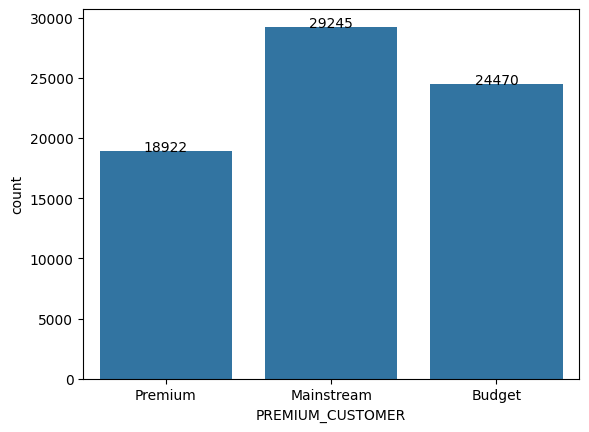

In [9]:
ax = sns.countplot(x='PREMIUM_CUSTOMER', data=df_purchase)
# annotate the bars
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2., height + 3,
            '{:1.0f}'.format(height),
            ha="center")

plt.show()

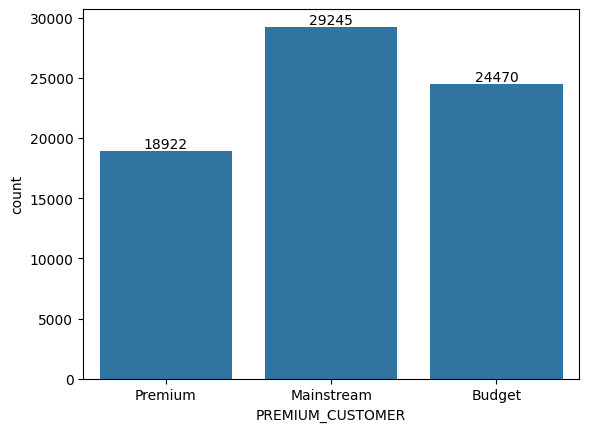

In [13]:
bar=sns.countplot(x='PREMIUM_CUSTOMER', data=df_purchase)
# annotate the bars
plt.bar_label(bar.containers[0])
plt.show()



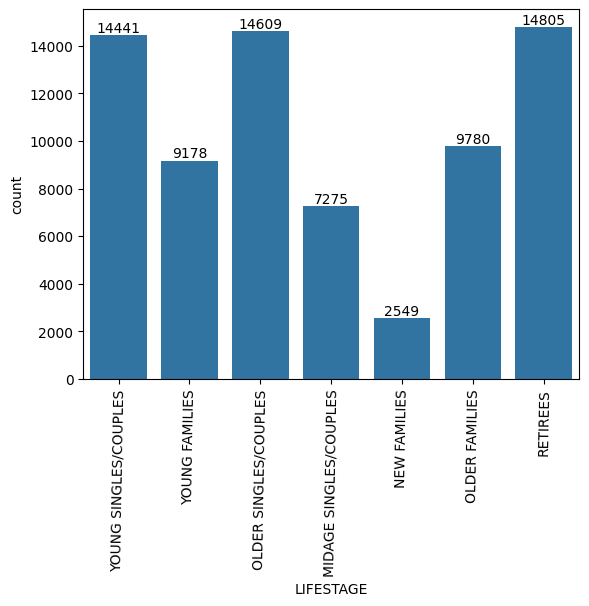

In [20]:
life_bar = sns.countplot(x='LIFESTAGE', data=df_purchase)
#annotation
plt.bar_label(life_bar.containers[0])
plt.xticks(rotation=89)
plt.show()

In [21]:
df_purchase.isnull().sum()

,0
LYLTY_CARD_NBR,0
LIFESTAGE,0
PREMIUM_CUSTOMER,0


In [31]:
df_purchase.duplicated().sum()

np.int64(0)

In [33]:
df_purchase[["PREMIUM_CUSTOMER","LIFESTAGE"]].value_counts()

PREMIUM_CUSTOMER  LIFESTAGE             
Mainstream        YOUNG SINGLES/COUPLES     8088
                  RETIREES                  6479
                  OLDER SINGLES/COUPLES     4930
Budget            OLDER SINGLES/COUPLES     4929
Premium           OLDER SINGLES/COUPLES     4750
Budget            OLDER FAMILIES            4675
                  RETIREES                  4454
                  YOUNG FAMILIES            4017
Premium           RETIREES                  3872
Budget            YOUNG SINGLES/COUPLES     3779
Mainstream        MIDAGE SINGLES/COUPLES    3340
                  OLDER FAMILIES            2831
                  YOUNG FAMILIES            2728
Premium           YOUNG SINGLES/COUPLES     2574
                  YOUNG FAMILIES            2433
                  MIDAGE SINGLES/COUPLES    2431
                  OLDER FAMILIES            2274
Budget            MIDAGE SINGLES/COUPLES    1504
                  NEW FAMILIES              1112
Mainstream        NEW FAMILIES               849
Premium           NEW FAMILIES               588
Name: count, dtype: int64

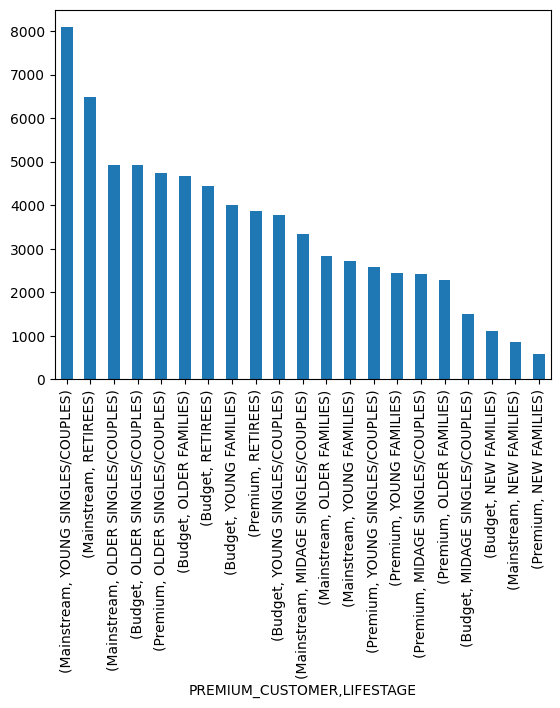

In [35]:
df_purchase[["PREMIUM_CUSTOMER","LIFESTAGE"]].value_counts().plot(kind='bar')
plt.show()

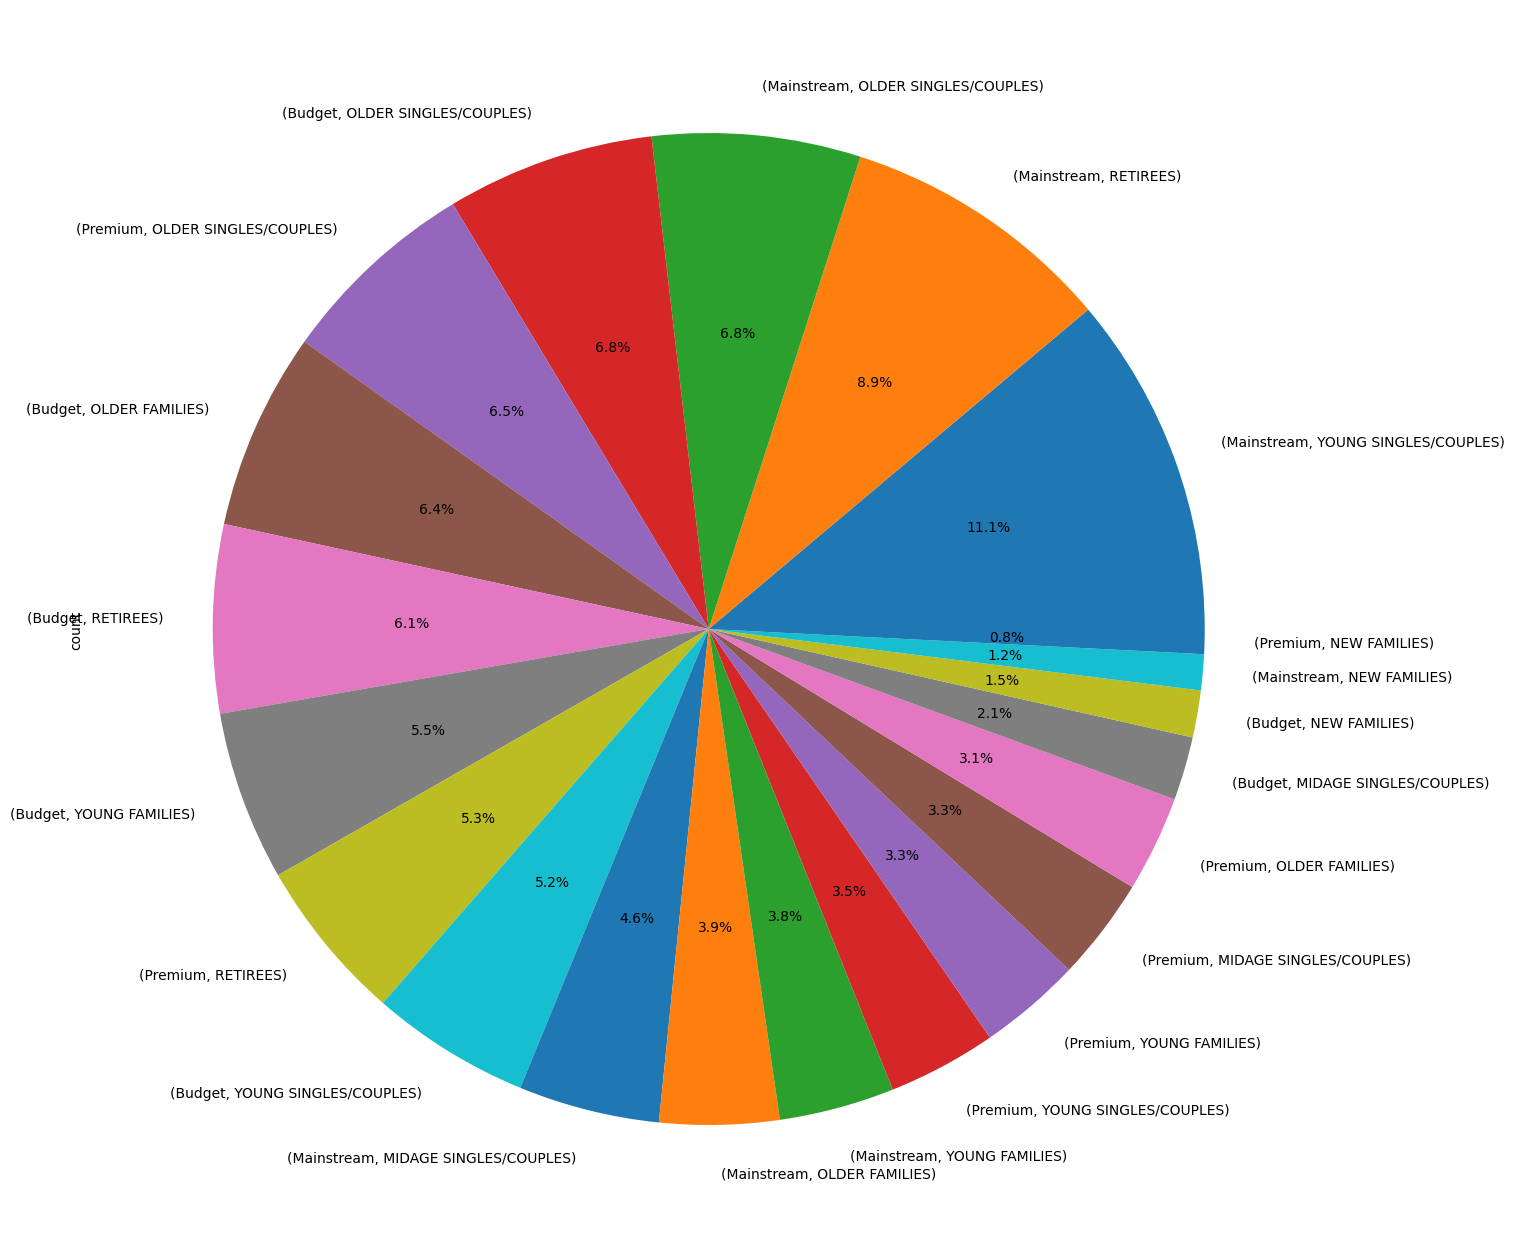

In [41]:
df_purchase[["PREMIUM_CUSTOMER","LIFESTAGE"]].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(16,26), )
plt.show()


In [45]:
# now use groupby for grouping with w.r.t preminym customers and lifestage
df_purchase.groupby('PREMIUM_CUSTOMER')['LIFESTAGE'].value_counts()

PREMIUM_CUSTOMER  LIFESTAGE             
Budget            OLDER SINGLES/COUPLES     4929
                  OLDER FAMILIES            4675
                  RETIREES                  4454
                  YOUNG FAMILIES            4017
                  YOUNG SINGLES/COUPLES     3779
                  MIDAGE SINGLES/COUPLES    1504
                  NEW FAMILIES              1112
Mainstream        YOUNG SINGLES/COUPLES     8088
                  RETIREES                  6479
                  OLDER SINGLES/COUPLES     4930
                  MIDAGE SINGLES/COUPLES    3340
                  OLDER FAMILIES            2831
                  YOUNG FAMILIES            2728
                  NEW FAMILIES               849
Premium           OLDER SINGLES/COUPLES     4750
                  RETIREES                  3872
                  YOUNG SINGLES/COUPLES     2574
                  YOUNG FAMILIES            2433
                  MIDAGE SINGLES/COUPLES    2431
                  OLDER FAMILIES            2274
                  NEW FAMILIES               588
Name: count, dtype: int64

In [46]:
df_purchase[["PREMIUM_CUSTOMER","LIFESTAGE"]].value_counts()

PREMIUM_CUSTOMER  LIFESTAGE             
Mainstream        YOUNG SINGLES/COUPLES     8088
                  RETIREES                  6479
                  OLDER SINGLES/COUPLES     4930
Budget            OLDER SINGLES/COUPLES     4929
Premium           OLDER SINGLES/COUPLES     4750
Budget            OLDER FAMILIES            4675
                  RETIREES                  4454
                  YOUNG FAMILIES            4017
Premium           RETIREES                  3872
Budget            YOUNG SINGLES/COUPLES     3779
Mainstream        MIDAGE SINGLES/COUPLES    3340
                  OLDER FAMILIES            2831
                  YOUNG FAMILIES            2728
Premium           YOUNG SINGLES/COUPLES     2574
                  YOUNG FAMILIES            2433
                  MIDAGE SINGLES/COUPLES    2431
                  OLDER FAMILIES            2274
Budget            MIDAGE SINGLES/COUPLES    1504
                  NEW FAMILIES              1112
Mainstream        NEW FAMILIES               849
Premium           NEW FAMILIES               588
Name: count, dtype: int64

In [22]:
df_transaction.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


In [23]:
df_transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [25]:
df_transaction.isna().sum()

,0
DATE,0
STORE_NBR,0
LYLTY_CARD_NBR,0
TXN_ID,0
PROD_NBR,0
PROD_NAME,0
PROD_QTY,0
TOT_SALES,0


In [32]:
# drop duplicates
print("The shape before drop", df_transaction.shape[0])
df_transaction.drop_duplicates(inplace =True)
print("The shape After drop", df_transaction.shape[0])


The shape before drop 264836
The shape After drop 264835


In [48]:
# only shows data, if PROD_NAME contain word chips or Chips
df_chips=df_transaction[df_transaction['PROD_NAME'].str.contains('chips|Chips')]
df_chips.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
6,43601,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7
10,43602,7,7215,7176,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7
14,43600,19,19272,16686,44,Thins Chips Light& Tangy 175g,1,3.3
33,43603,45,45220,41651,22,Thins Chips Originl saltd 175g,1,3.3


In [52]:
# most top 6 chips by store number
df_chips[['STORE_NBR', "PROD_NAME"]].value_counts()[:6]

,,count
STORE_NBR,PROD_NAME,
88,Cobs Popd Sour Crm &Chives Chips 110g,48
226,Thins Chips Seasonedchicken 175g,47
201,Thins Potato Chips Hot & Spicy 175g,44
237,Thins Potato Chips Hot & Spicy 175g,44
226,Smiths Crinkle Chips Salt & Vinegar 330g,44
237,Cobs Popd Sea Salt Chips 110g,44


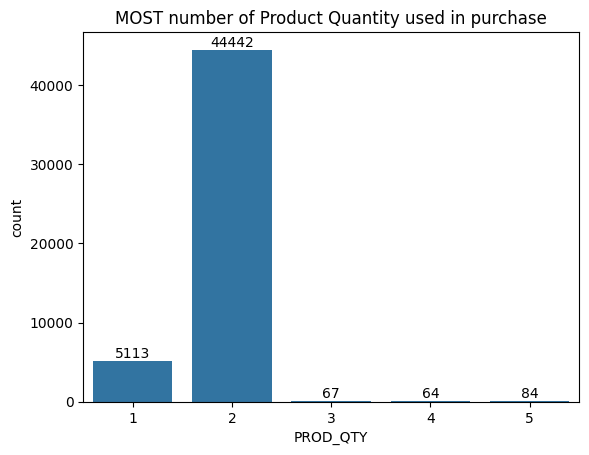

In [56]:
product_numb =sns.countplot(x='PROD_QTY', data=df_chips)
plt.bar_label(product_numb.containers[0])
plt.title('MOST number of Product Quantity used in purchase')
plt.show()

In [57]:
#average sale per chips
df_chips.groupby('PROD_NAME')['TOT_SALES'].mean()


,TOT_SALES
PROD_NAME,
Cobs Popd Sea Salt Chips 110g,7.305544
Cobs Popd Sour Crm &Chives Chips 110g,7.263185
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g,7.272193
Doritos Corn Chips Cheese Supreme 170g,8.449860
Doritos Corn Chips Nacho Cheese 170g,8.405949
Doritos Corn Chips Original 170g,8.403845
French Fries Potato Chips 175g,5.591678
Smiths Crinkle Chips Salt & Vinegar 330g,10.886519
Smiths Crinkle Cut Chips Barbecue 170g,5.457220


In [58]:
df_chips.groupby('PROD_NAME')['TOT_SALES'].median()

,TOT_SALES
PROD_NAME,
Cobs Popd Sea Salt Chips 110g,7.6
Cobs Popd Sour Crm &Chives Chips 110g,7.6
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g,7.6
Doritos Corn Chips Cheese Supreme 170g,8.8
Doritos Corn Chips Nacho Cheese 170g,8.8
Doritos Corn Chips Original 170g,8.8
French Fries Potato Chips 175g,6.0
Smiths Crinkle Chips Salt & Vinegar 330g,11.4
Smiths Crinkle Cut Chips Barbecue 170g,5.8


In [59]:
df_chips.groupby('PROD_NAME')['TOT_SALES'].sum()

,TOT_SALES
PROD_NAME,
Cobs Popd Sea Salt Chips 110g,23852.6
Cobs Popd Sour Crm &Chives Chips 110g,22944.4
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g,23772.8
Doritos Corn Chips Cheese Supreme 170g,27183.2
Doritos Corn Chips Nacho Cheese 170g,26562.8
Doritos Corn Chips Original 170g,26228.4
French Fries Potato Chips 175g,7929.0
Smiths Crinkle Chips Salt & Vinegar 330g,34804.2
Smiths Crinkle Cut Chips Barbecue 170g,8125.8


In [60]:
df_chips.groupby('PROD_NAME')['TOT_SALES'].describe()

,count,mean,std,min,25%,50%,75%,max
PROD_NAME,,,,,,,,
Cobs Popd Sea Salt Chips 110g,3265.0,7.305544,1.169945,3.8,7.6,7.6,7.6,19.0
Cobs Popd Sour Crm &Chives Chips 110g,3159.0,7.263185,1.277975,3.8,7.6,7.6,7.6,19.0
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g,3269.0,7.272193,1.228706,3.8,7.6,7.6,7.6,19.0
Doritos Corn Chips Cheese Supreme 170g,3217.0,8.449860,1.442445,4.4,8.8,8.8,8.8,22.0
Doritos Corn Chips Nacho Cheese 170g,3160.0,8.405949,1.404020,4.4,8.8,8.8,8.8,22.0
Doritos Corn Chips Original 170g,3121.0,8.403845,1.390733,4.4,8.8,8.8,8.8,22.0
French Fries Potato Chips 175g,1418.0,5.591678,1.065459,3.0,6.0,6.0,6.0,9.0
Smiths Crinkle Chips Salt & Vinegar 330g,3197.0,10.886519,1.837287,5.7,11.4,11.4,11.4,28.5
Smiths Crinkle Cut Chips Barbecue 170g,1489.0,5.457220,1.133177,2.9,5.8,5.8,5.8,14.5


In [61]:
df_chips.groupby('PROD_NAME')['TOT_SALES'].describe().sort_values(by='mean', ascending=False)

,count,mean,std,min,25%,50%,75%,max
PROD_NAME,,,,,,,,
Smiths Crinkle Chips Salt & Vinegar 330g,3197.0,10.886519,1.837287,5.7,11.4,11.4,11.4,28.5
Doritos Corn Chips Cheese Supreme 170g,3217.0,8.449860,1.442445,4.4,8.8,8.8,8.8,22.0
Doritos Corn Chips Nacho Cheese 170g,3160.0,8.405949,1.404020,4.4,8.8,8.8,8.8,22.0
Doritos Corn Chips Original 170g,3121.0,8.403845,1.390733,4.4,8.8,8.8,8.8,22.0
Cobs Popd Sea Salt Chips 110g,3265.0,7.305544,1.169945,3.8,7.6,7.6,7.6,19.0
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g,3269.0,7.272193,1.228706,3.8,7.6,7.6,7.6,19.0
Cobs Popd Sour Crm &Chives Chips 110g,3159.0,7.263185,1.277975,3.8,7.6,7.6,7.6,19.0
Thins Chips Seasonedchicken 175g,3114.0,6.343545,1.108403,3.3,6.6,6.6,6.6,16.5
Thins Potato Chips Hot & Spicy 175g,3229.0,6.320997,1.070865,3.3,6.6,6.6,6.6,16.5


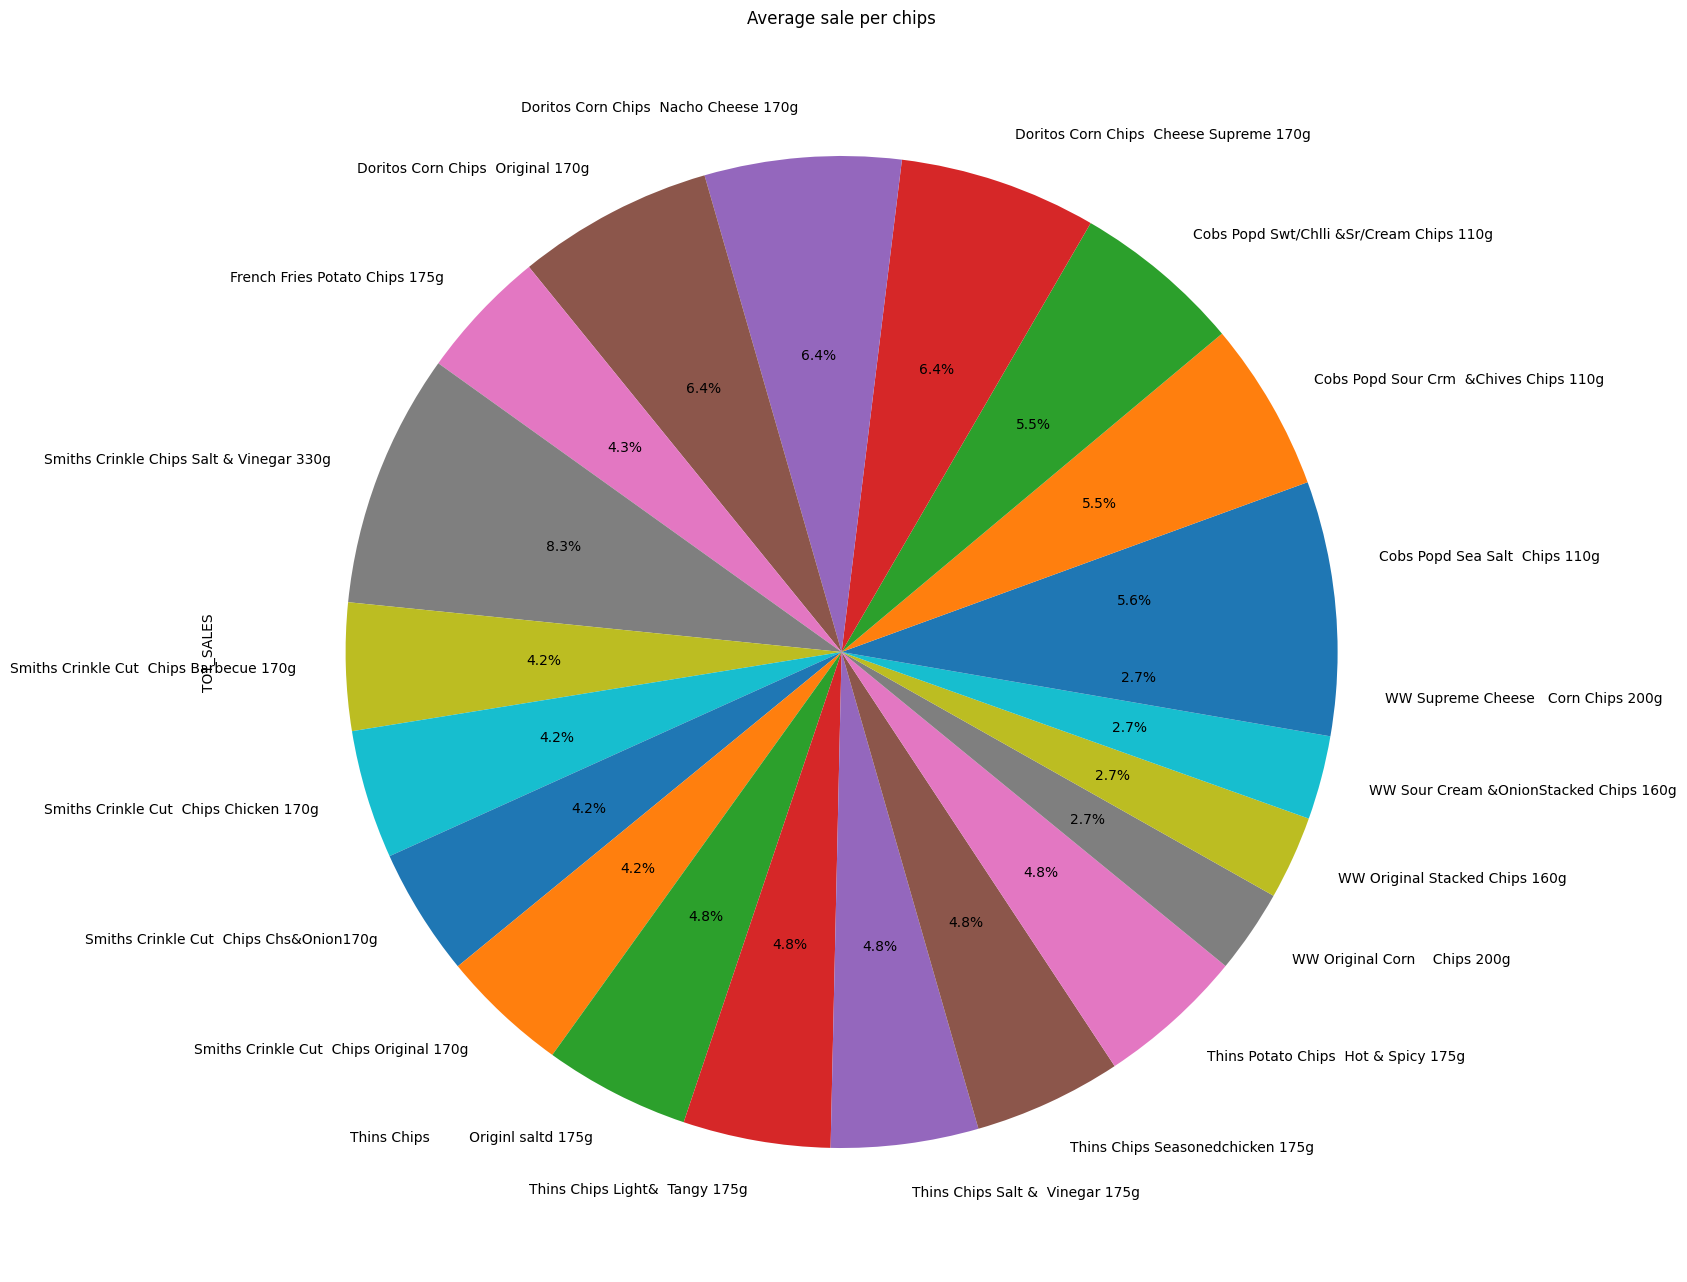

In [63]:
#average sale per chips
df_chips.groupby('PROD_NAME')['TOT_SALES'].mean().plot(kind='pie', autopct='%1.1f%%', figsize=(16,26), )
plt.title('Average sale per chips')
plt.show()

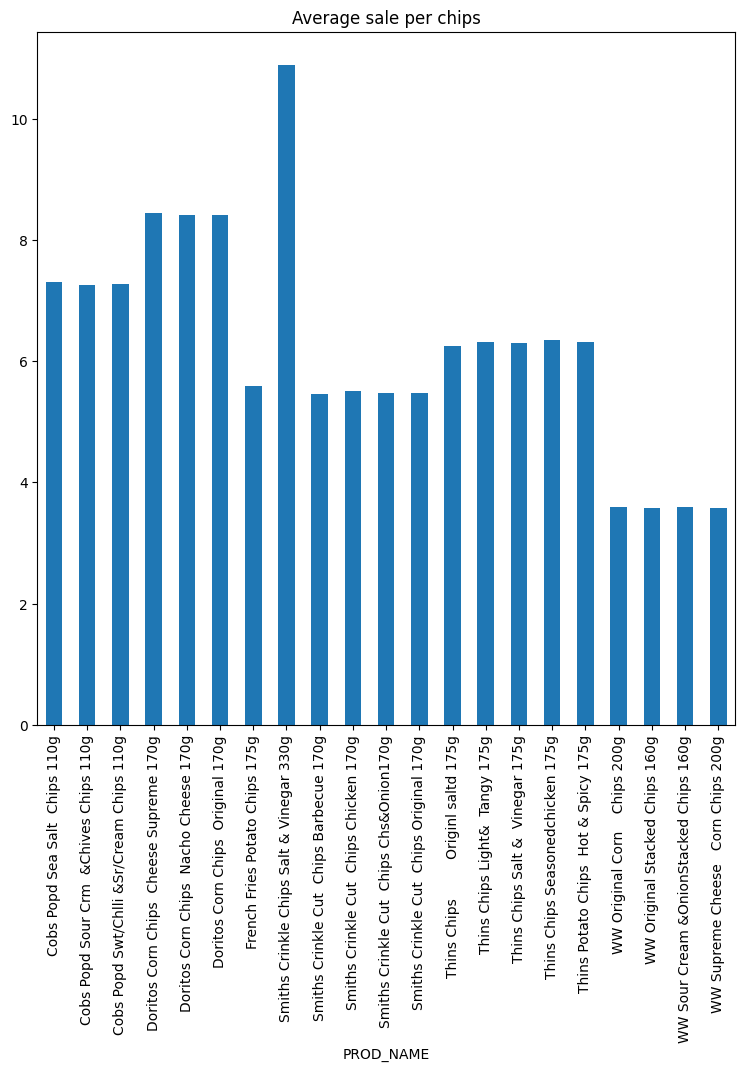

In [70]:
#average sale per chips
df_chips.groupby('PROD_NAME')['TOT_SALES'].mean().plot(kind='bar',  figsize=(9,9) )
plt.title('Average sale per chips')
plt.show()

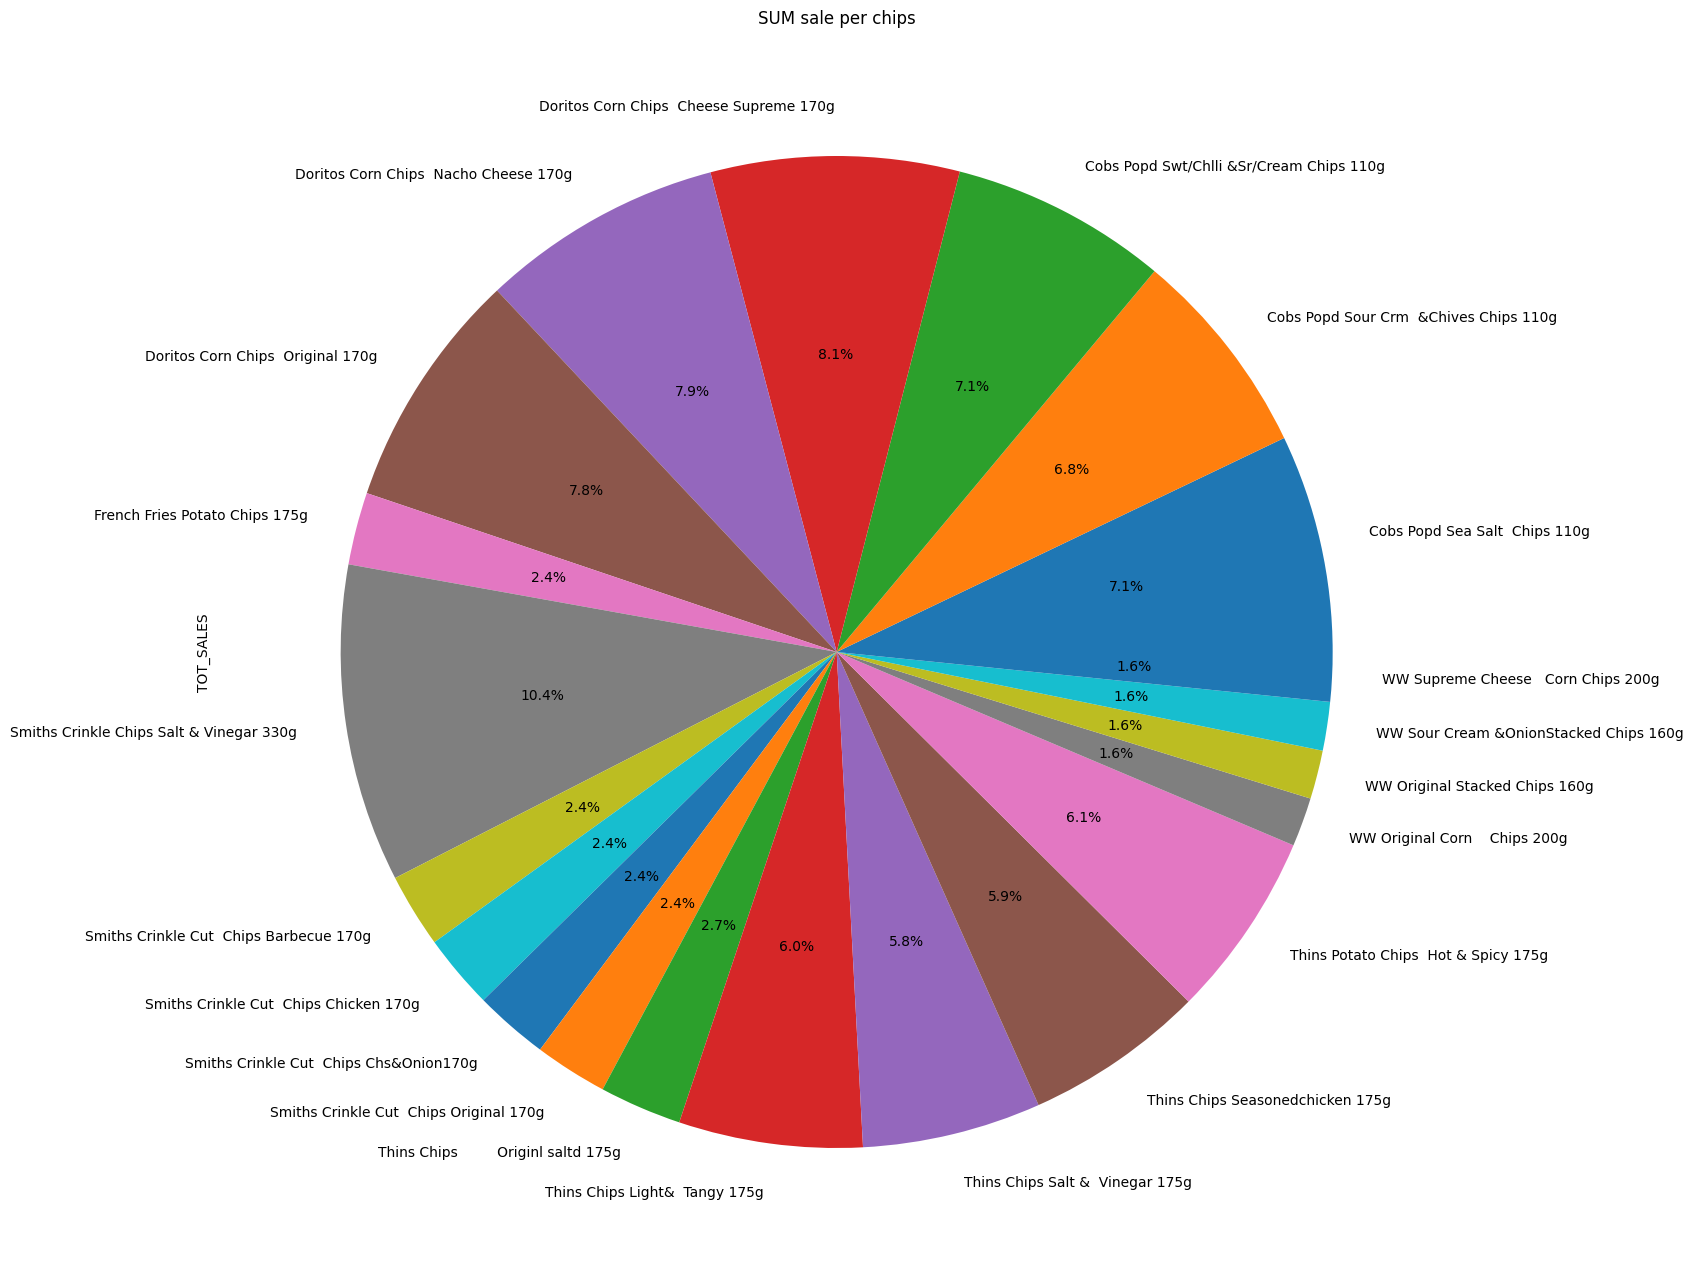

In [64]:
#average sale per chips
df_chips.groupby('PROD_NAME')['TOT_SALES'].sum().plot(kind='pie', autopct='%1.1f%%', figsize=(16,26), )
plt.title('SUM sale per chips')
plt.show()

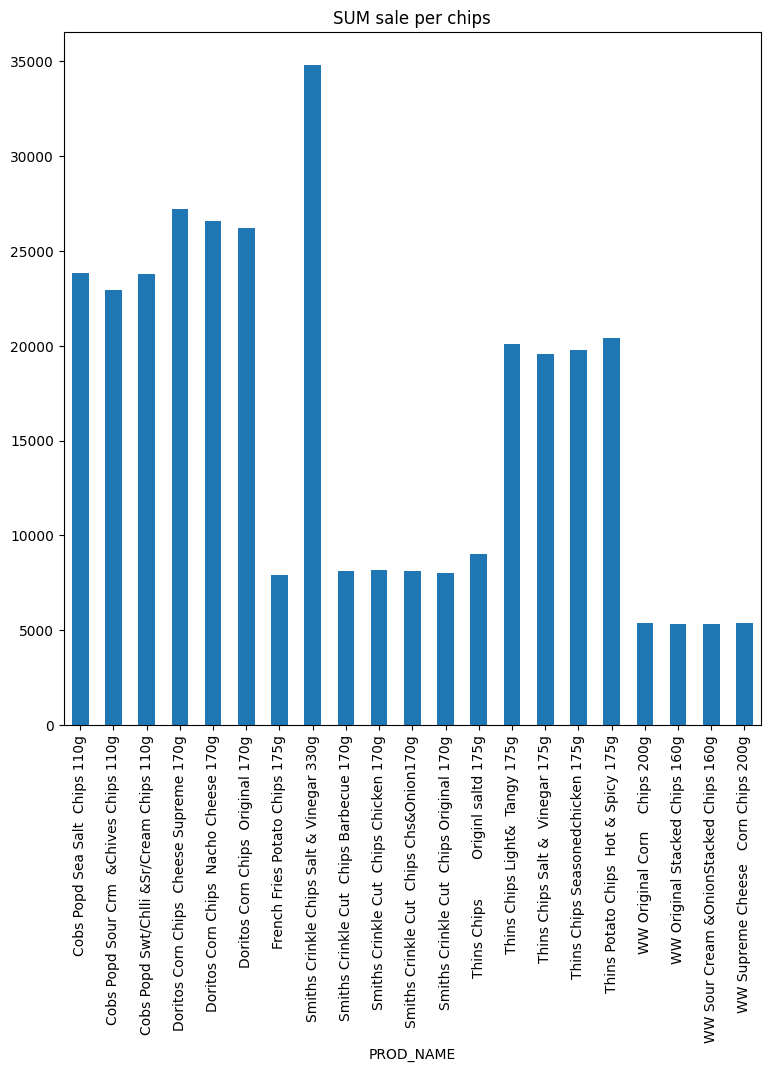

In [71]:
df_chips.groupby('PROD_NAME')['TOT_SALES'].sum().plot(kind='bar', figsize=(9,9), )
plt.title('SUM sale per chips')
plt.show()